# Trementum — Analytics Test Task

**Aim of this test task:** to assess your skills in analytical thinking and providing informative data insights in English.


**Task:** Perform an exploratory data analysis (EDA) to uncover insights and summarize your findings.


**Deliverables:**
 - A concise report with your EDA process, visualizations, and key insights.
 - SQL queries and Python code used in your analysis.

## 1. Introduction

For the analysis, we used the `test_sample.csv` file, which has data about user posts on different platforms, including the number of likes, shares, comments, and views. The work has several steps: data preparation, description, analysis, and drawing conclusions based on the results.


In [ ]:
!pip install langdetect

In [ ]:
# Libraries
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from langdetect import detect, DetectorFactory
from collections import Counter

In [ ]:
csv_file_path = '/content/drive/MyDrive/test_sample.csv'

df = pd.read_csv(csv_file_path, engine='python')

## 2. Data Preparation

* Remove rows where the number of non-empty values is below a set threshold.
* Convert features to the correct data types for further analysis.


In [ ]:
print(f"DataFrame size before dropping rows: {df.shape}")

# Set threshold: minimum number of non-empty values to keep a row.
# For example, keep rows with at least 30% of columns filled.
threshold_percentage = 0.7
min_non_null_columns = int(df.shape[1] * threshold_percentage)

print(f"Rows with fewer than {min_non_null_columns} non-empty values (which is {threshold_percentage*100}% of all columns) will be removed.")

# Drop rows with fewer non-empty values than the threshold
df_cleaned = df.dropna(thresh=min_non_null_columns).copy()

print(f"DataFrame size after dropping rows: {df_cleaned.shape}")

DataFrame size before dropping rows: (10525, 10)
Rows with fewer than 7 non-empty values (which is 70.0% of all columns) will be removed.
DataFrame size after dropping rows: (9337, 10)


In [ ]:
# Convert columns to correct data types
df_cleaned['platform'] = df_cleaned['platform'].astype('category')
df_cleaned['created_time'] = pd.to_datetime(df_cleaned['created_time'], errors='coerce')

## 3. Data Description

* Display the cleaned data table.
* Show the data types of the table’s attributes.
* Example of a user post from a row in the table.


In [ ]:
# Show the first 10 rows of the cleaned DataFrame
df_cleaned.head(10)

,platform,account_id,id,created_time,text_original,text_additional,likes_count,shares_count,comments_count,views_count
1,Instagram,60554087008,C_00W8KttVv,2024-09-12 17:21:27+00:00,C’è un gruppo sulla parola di Dio sulla mia ho...,NaN,391.0,NaN,37.0,NaN
2,Instagram,62605500679,C_026U_t3We,2024-09-12 17:43:38+00:00,𝐒𝐮𝐥 𝐦𝐢𝐨 𝐩𝐫𝐨𝐟𝐢𝐥𝐨 𝐜‘𝐞̀ 𝐮𝐧 𝐠𝐫𝐮𝐩𝐩𝐨 𝐝𝐢 𝐬𝐭𝐮𝐝𝐢𝐨 𝐬𝐮𝐥𝐥𝐚...,NaN,9.0,NaN,3.0,NaN
3,Instagram,58741537308,C_05B3hCYQn,2024-09-12 18:02:08+00:00,#Monza\n#Padova\n#Lecce\n#Latina\n#paroladelsi...,NaN,78.0,NaN,15.0,NaN
4,Instagram,58741537308,C_0BfOLiqRS,2024-09-12 09:57:22+00:00,#Monza\n#Padova\n#Lecce\n#Latina\n#paroladelsi...,NaN,129.0,NaN,16.0,NaN
5,Instagram,60554087008,C-0bWHPCJS2,2024-08-18 17:11:50+00:00,𝑺𝙪𝒍 𝒎𝙞𝒐 𝒑𝙧𝒐𝙛𝒊𝙡𝒐 𝒄‘𝒆̀ 𝒖𝙣 𝙜𝒓𝙪𝒑𝙥𝒐 𝒅𝙞 𝙨𝒕𝙪𝒅𝙞𝒐 𝒔𝙪𝒍𝙡𝒂...,NaN,225.0,NaN,41.0,NaN
6,Instagram,61867718379,C_0hjXWysdP,2024-09-12 14:37:07+00:00,"Завтра може бути занадто пізно, тому, будь лас...",NaN,84.0,NaN,43.0,NaN
7,Instagram,58769017625,C-0HUY8iqNc,2024-08-18 14:16:22+00:00,#signore,NaN,1123.0,NaN,80.0,NaN
8,Instagram,59141296785,C-0IPrsic_l,2024-08-18 14:24:28+00:00,#signore,NaN,353.0,NaN,45.0,NaN
9,Instagram,61344079846,C_0KxedyBAe,2024-09-12 11:17:57+00:00,你以为的幸运\n其实都是耶稣的保守\n\n人生的每一步都不是偶然\n哪有人无缘无故爱你\n哪...,NaN,1088.0,NaN,276.0,NaN
10,Instagram,60554087008,C_0mvxptncV,2024-09-12 15:22:23+00:00,𝙏𝙤𝙘𝙘𝙖 𝙞𝙡 𝙡𝙞𝙣𝙠 𝙙𝙞 𝙒𝙝𝙖𝙩𝙨𝘼𝙥𝙥 𝙘𝙝𝙚 𝙩𝙧𝙤𝙫𝙞 𝙣𝙚𝙡 𝙢𝙞𝙤 𝙥𝙧...,NaN,230.0,NaN,18.0,NaN


In [ ]:
# Show data types of columns
df_cleaned.dtypes.to_frame(name="data_type")

,data_type
platform,category
account_id,object
id,object
created_time,"datetime64[ns, UTC]"
text_original,object
text_additional,object
likes_count,float64
shares_count,float64
comments_count,float64
views_count,float64


### 3.3 Example of a user post from a row in the table

| platform  | account_id   | id             | created_time                     | text_original | text_additional | likes_count | shares_count | comments_count | views_count |
|-----------|--------------|----------------|---------------------------------|---------------|----------------|------------|--------------|----------------|------------|
| Instagram | 60554087008  | C-0bWHPCJS2    | 2024-08-18 17:11:50.000000+00:00 | "𝑺𝙪𝒍 𝒎𝙞𝒐 𝒑𝙧𝒐𝙛𝒊𝙡𝒐 𝒄‘𝒆̀ 𝒖𝙣 𝙜𝒓𝙪𝒑𝙥𝙤 ..." |                | 225        |              | 41             |            |

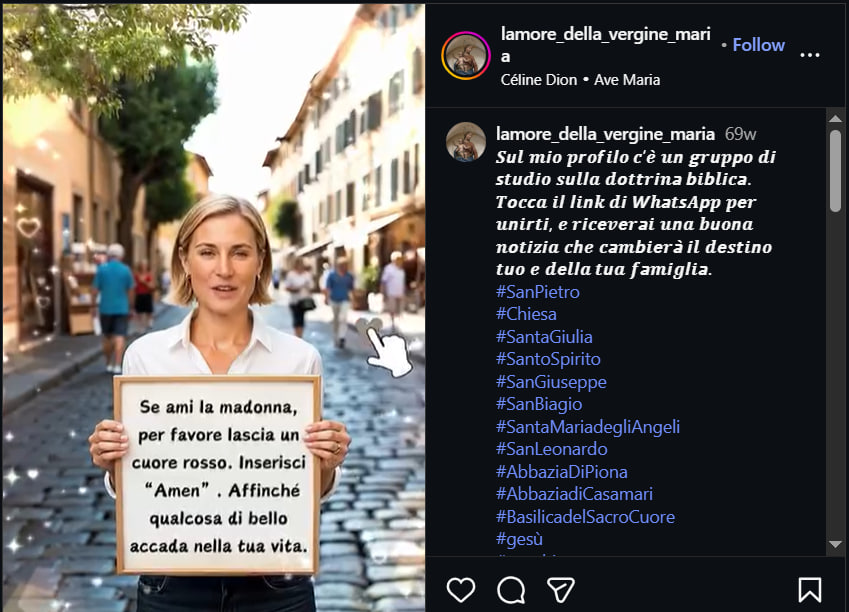


## 4. Analysis

* Posts and activity by platform.
* Number of unique accounts and top active users.
* Popular times and weekdays for posting.
* Statistics and correlation of engagement metrics.
* Language and text analysis of posts.


### 4.1 Posts and Activity by Platform

We count the number of posts on each platform and sum the main engagement metrics (likes, shares, comments, views).
This helps to see which platforms are the most active and where the audience interacts with content the most.


In [ ]:
# Count the number of posts for each platform
df_cleaned['platform'].value_counts()

,count
platform,
Facebook,2500
TikTok,2500
YouTube,2500
Instagram,1837


In [ ]:
# Sum engagement metrics (likes, shares, comments, views) for each platform
# to evaluate overall activity and audience engagement on each platform
df_cleaned.groupby('platform', observed=False)[['likes_count', 'shares_count', 'comments_count', 'views_count']].sum()

,likes_count,shares_count,comments_count,views_count
platform,,,,
Facebook,855909.0,163190.0,1112312.0,4371149.0
Instagram,2801978.0,0.0,411721.0,0.0
TikTok,3786344.0,232970.0,950179.0,39739895.0
YouTube,5744059.0,0.0,340304.0,56918162.0


### 4.2 Number of Unique Accounts and Top Active Users

Analyzing the number of unique accounts and their share of total posts, as well as identifying the most active accounts by post count and total engagement (likes, shares, comments, and views), helps to understand how activity is distributed among users and to identify the most influential accounts.


In [ ]:
# Calculate total number of records with account_id, number of unique accounts
# and their ratio to all records to understand activity distribution among users
total_account_ids = df_cleaned['account_id'].count()
unique_account_ids = df_cleaned['account_id'].nunique()
ratio = unique_account_ids / total_account_ids

print(f"Total number of non-empty account_ids: {total_account_ids}")
print(f"Number of unique account_ids: {unique_account_ids}")
print(f"Ratio of unique IDs to total: {ratio:.2%}")

Total number of non-empty account_ids: 9337
Number of unique account_ids: 101
Ratio of unique IDs to total: 1.08%


In [ ]:
# 1. Top accounts by number of posts
top_accounts_posts = df_cleaned['account_id'].value_counts().head(15)
print("Top 10 accounts by number of posts:")
display(top_accounts_posts)

Top 10 accounts by number of posts:


,count
account_id,
UCnCTdYt9SicG9-yrlf-0GbQ,409
7308760731372291104,386
UCEaVXzCYOxl77NFD8U97q5A,365
62605500679,360
58769017625,345
7301606688049054752,345
UCZDp5opaZqL3_jed23UU--g,324
100092726436702,294
61867718379,292


In [ ]:
# 2. Top accounts by total engagement (likes, shares, comments, views)
top_accounts_engagement = (
    df_cleaned
    .groupby('account_id')[['likes_count', 'shares_count', 'comments_count', 'views_count']]
    .sum()
    .sort_values('likes_count', ascending=False)
    .head(10)
)
top_accounts_engagement['platform'] = df_cleaned.groupby('account_id')['platform'].first()

print("Top 10 accounts by engagement (likes, shares, comments, views):")
display(top_accounts_engagement)

Top 10 accounts by engagement (likes, shares, comments, views):


,likes_count,shares_count,comments_count,views_count,platform
account_id,,,,,
UCnCTdYt9SicG9-yrlf-0GbQ,1638554.0,0.0,64557.0,14063525.0,YouTube
UC3pF1tXsYI8Xme1oxciBXfw,1274262.0,0.0,53544.0,10530332.0,YouTube
UCZDp5opaZqL3_jed23UU--g,1251440.0,0.0,51828.0,14015351.0,YouTube
58769017625,1081101.0,0.0,172735.0,0.0,Instagram
60554087008,697595.0,0.0,66645.0,0.0,Instagram
UCzZX_eiTTwqBk7EugaT9z4Q,678410.0,0.0,29700.0,8623278.0,YouTube
6793090586712720389,631857.0,26929.0,157613.0,5966453.0,TikTok
7308760731372291104,563722.0,9236.0,169170.0,6872900.0,TikTok
7301606688049054752,521147.0,17245.0,95129.0,4469581.0,TikTok


### 4.3 Popular Posting Times and Weekdays

This section analyzes which weekdays and hours posts are published, identifies the most popular posting times, and shows the top 5 days and hours by activity.
It helps to understand when the audience is most active and optimize content posting times.


In [ ]:
df_cleaned_time = df_cleaned.dropna(subset=['created_time']).copy()

# Extract day of the week and hour
df_cleaned_time['day_of_week'] = df_cleaned_time['created_time'].dt.day_name()
df_cleaned_time['hour_of_day'] = df_cleaned_time['created_time'].dt.hour

print("DataFrame size after processing created_time and removing invalid values:", df_cleaned_time.shape)

# Most common day of the week
most_common_day = df_cleaned_time['day_of_week'].mode()[0]
print(f"Posts are most often made on: {most_common_day}")

# Most common hour
most_common_hour = df_cleaned_time['hour_of_day'].mode()[0]
print(f"Posts are most often made at {most_common_hour}:00 hours")

# Top 5 weekdays by post frequency
print("\nTop 5 weekdays by post frequency:")
display(df_cleaned_time['day_of_week'].value_counts().head(5))

# Top 5 hours by post frequency
print("\nTop 5 hours by post frequency:")
display(df_cleaned_time['hour_of_day'].value_counts().head(5))

DataFrame size after processing created_time and removing invalid values: (9337, 12)
Posts are most often made on: Monday
Posts are most often made at 9:00 hours

Top 5 weekdays by post frequency:


,count
day_of_week,
Monday,1400
Friday,1387
Wednesday,1327
Sunday,1321
Tuesday,1310



Top 5 hours by post frequency:


,count
hour_of_day,
9,861
5,812
15,757
17,743
10,637


### 4.4 Statistics and Correlation of Engagement Metrics

We calculate basic statistics for engagement metrics (likes, shares, comments, views) and create visualizations: a boxplot to show value distribution and outliers, and a heatmap to check correlations between metrics.
This helps to understand the range of values, spot anomalies, and see how different types of engagement are related.


Engagement metrics statistics:


,likes_count,shares_count,comments_count,views_count
count,9337.00,5000.00,9319.00,5621.00
mean,1412.48,79.23,302.02,17973.53
std,6116.80,979.56,1291.62,101249.23
min,0.00,0.00,0.00,3.00
25%,113.00,3.00,28.00,1539.00
50%,347.00,9.00,92.00,3704.00
75%,875.00,43.00,260.50,8535.00
max,188611.00,47500.00,80415.00,3500000.00


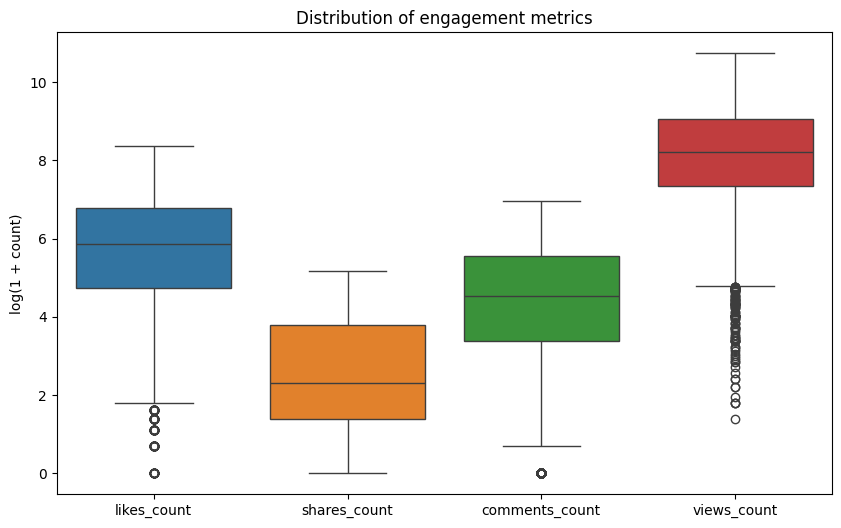

In [ ]:
# Select engagement metrics
engagement_metrics = ['likes_count', 'shares_count', 'comments_count', 'views_count']

# 1. Basic statistics (mean, median, min, max, std)
engagement_stats = df_cleaned[engagement_metrics].describe().round(2)
print("Engagement metrics statistics:")
display(engagement_stats)

# Apply log(1 + x) to reduce outliers
df_log = np.log1p(df_cleaned[engagement_metrics])

# Get the 95th percentile for the log-transformed data
upper_limits = df_log.quantile(0.95, axis=0)

# Clip values by the upper limit
df_clipped = df_log.clip(upper=upper_limits, axis=1)

# Plot boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clipped)
plt.title("Distribution of engagement metrics")
plt.ylabel("log(1 + count)")
plt.show()

Correlation between engagement metrics:


,likes_count,shares_count,comments_count,views_count
likes_count,1.00,0.76,0.53,0.92
shares_count,0.76,1.00,0.54,0.89
comments_count,0.53,0.54,1.00,0.50
views_count,0.92,0.89,0.50,1.00


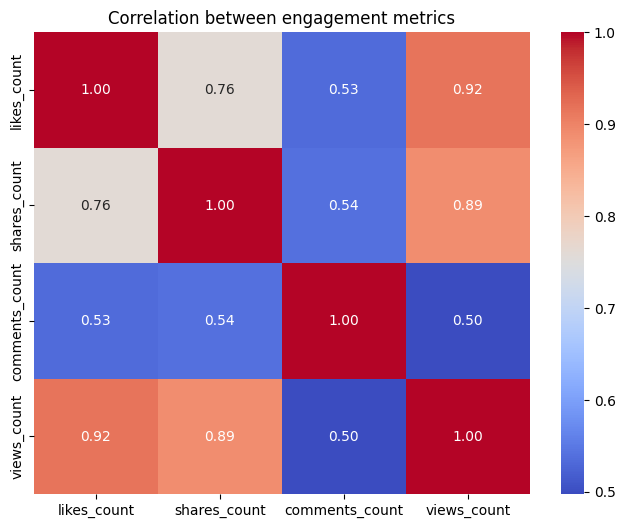

In [ ]:
# Heatmap: correlation between engagement metrics
engagement_corr = df_cleaned[engagement_metrics].corr()
print("Correlation between engagement metrics:")
display(engagement_corr.round(2))

plt.figure(figsize=(8, 6))
sns.heatmap(df_cleaned[engagement_metrics].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation between engagement metrics")
plt.show()

### 4.5 Language and Post Text Analysis

In this section, we identify the language of each post and analyze engagement metrics by language: counting the number of posts, total and average engagement, and finding the platform with the most posts for each language.
We also analyze text length (in words and characters) and its effect on engagement, and identify the most popular hashtags.
This helps to understand which languages and content formats attract the most audience, which platforms they are most active on, and which topics get the most attention.


In [ ]:
DetectorFactory.seed = 0  # fix result for reproducibility

# Function for safe language detection
def detect_language(text):
    try:
        return detect(text)
    except:
        return 'unknown'

# Detect language of posts
df_cleaned['language'] = df_cleaned['text_original'].fillna('').apply(detect_language)

# Count posts for each language
language_counts = df_cleaned['language'].value_counts().rename("post_count")

# Sum engagement metrics by language
language_engagement = df_cleaned.groupby('language', observed=False)[['likes_count', 'shares_count', 'comments_count', 'views_count']].sum()

# Combine post counts and engagement metrics
language_stats = pd.concat([language_counts, language_engagement], axis=1)

print("Engagement metrics and post counts by language:")
display(language_stats.head(10))

Engagement metrics and post counts by language:


,post_count,likes_count,shares_count,comments_count,views_count
language,,,,,
it,2374,3949428.0,126919.0,819161.0,17361798.0
uk,2155,5503170.0,297.0,283589.0,52752566.0
unknown,1812,690806.0,107092.0,634105.0,3148353.0
pl,1473,1504240.0,40000.0,437634.0,14982298.0
fr,312,144417.0,386.0,55727.0,1354182.0
es,303,271192.0,27322.0,259946.0,2553667.0
pt,238,309613.0,70187.0,149839.0,5451949.0
ko,147,141778.0,0.0,15910.0,1760.0
ru,116,143880.0,21.0,9414.0,1150388.0


In [ ]:
# Calculate average engagement per post for each language
language_avg = (
    df_cleaned
    .groupby('language')[['likes_count', 'shares_count', 'comments_count', 'views_count']]
    .mean()
    .sort_values('likes_count', ascending=False)
)

display(language_avg.head(10).round(2))

,likes_count,shares_count,comments_count,views_count
language,,,,
id,10789.00,3.50,1354.20,1940.00
tl,3433.89,177.00,512.68,NaN
cs,3372.00,NaN,563.00,NaN
da,3169.50,NaN,510.67,NaN
en,2898.89,255.75,999.22,23860.00
uk,2553.68,59.40,132.58,28209.93
so,2081.75,26.00,555.50,12885.33
ca,2028.83,2448.60,734.50,101245.80
it,1663.62,129.64,345.06,17275.42


In [ ]:
# Calculate the number of posts and average likes per post
language_stats = df_cleaned.groupby('language').agg(
    post_count=('id', 'count'),
    avg_likes=('likes_count', 'mean')
).sort_values('avg_likes', ascending=False)

display(language_stats.head(10).round(2))

,post_count,avg_likes
language,,
id,5,10789.00
tl,19,3433.89
cs,1,3372.00
da,6,3169.50
en,27,2898.89
uk,2155,2553.68
so,4,2081.75
ca,6,2028.83
it,2374,1663.62


In [ ]:
# Find the platform with the most posts for each language
platform_by_language = df_cleaned.groupby(['language', 'platform'], observed=False).size().reset_index(name='post_count')
platform_by_language = platform_by_language[platform_by_language['post_count'] >= 10]
platform_max_per_language = platform_by_language.loc[platform_by_language.groupby('language')['post_count'].idxmax()].reset_index(drop=True)

print("Platform with the most posts for each language:")
display(platform_max_per_language.head(10))

Platform with the most posts for each language:


,language,platform,post_count
0,bg,Instagram,49
1,en,YouTube,15
2,es,Facebook,280
3,fr,YouTube,279
4,hu,Facebook,10
5,it,Instagram,1197
6,ko,Instagram,144
7,lt,Facebook,23
8,nl,Facebook,23
9,pl,TikTok,1310


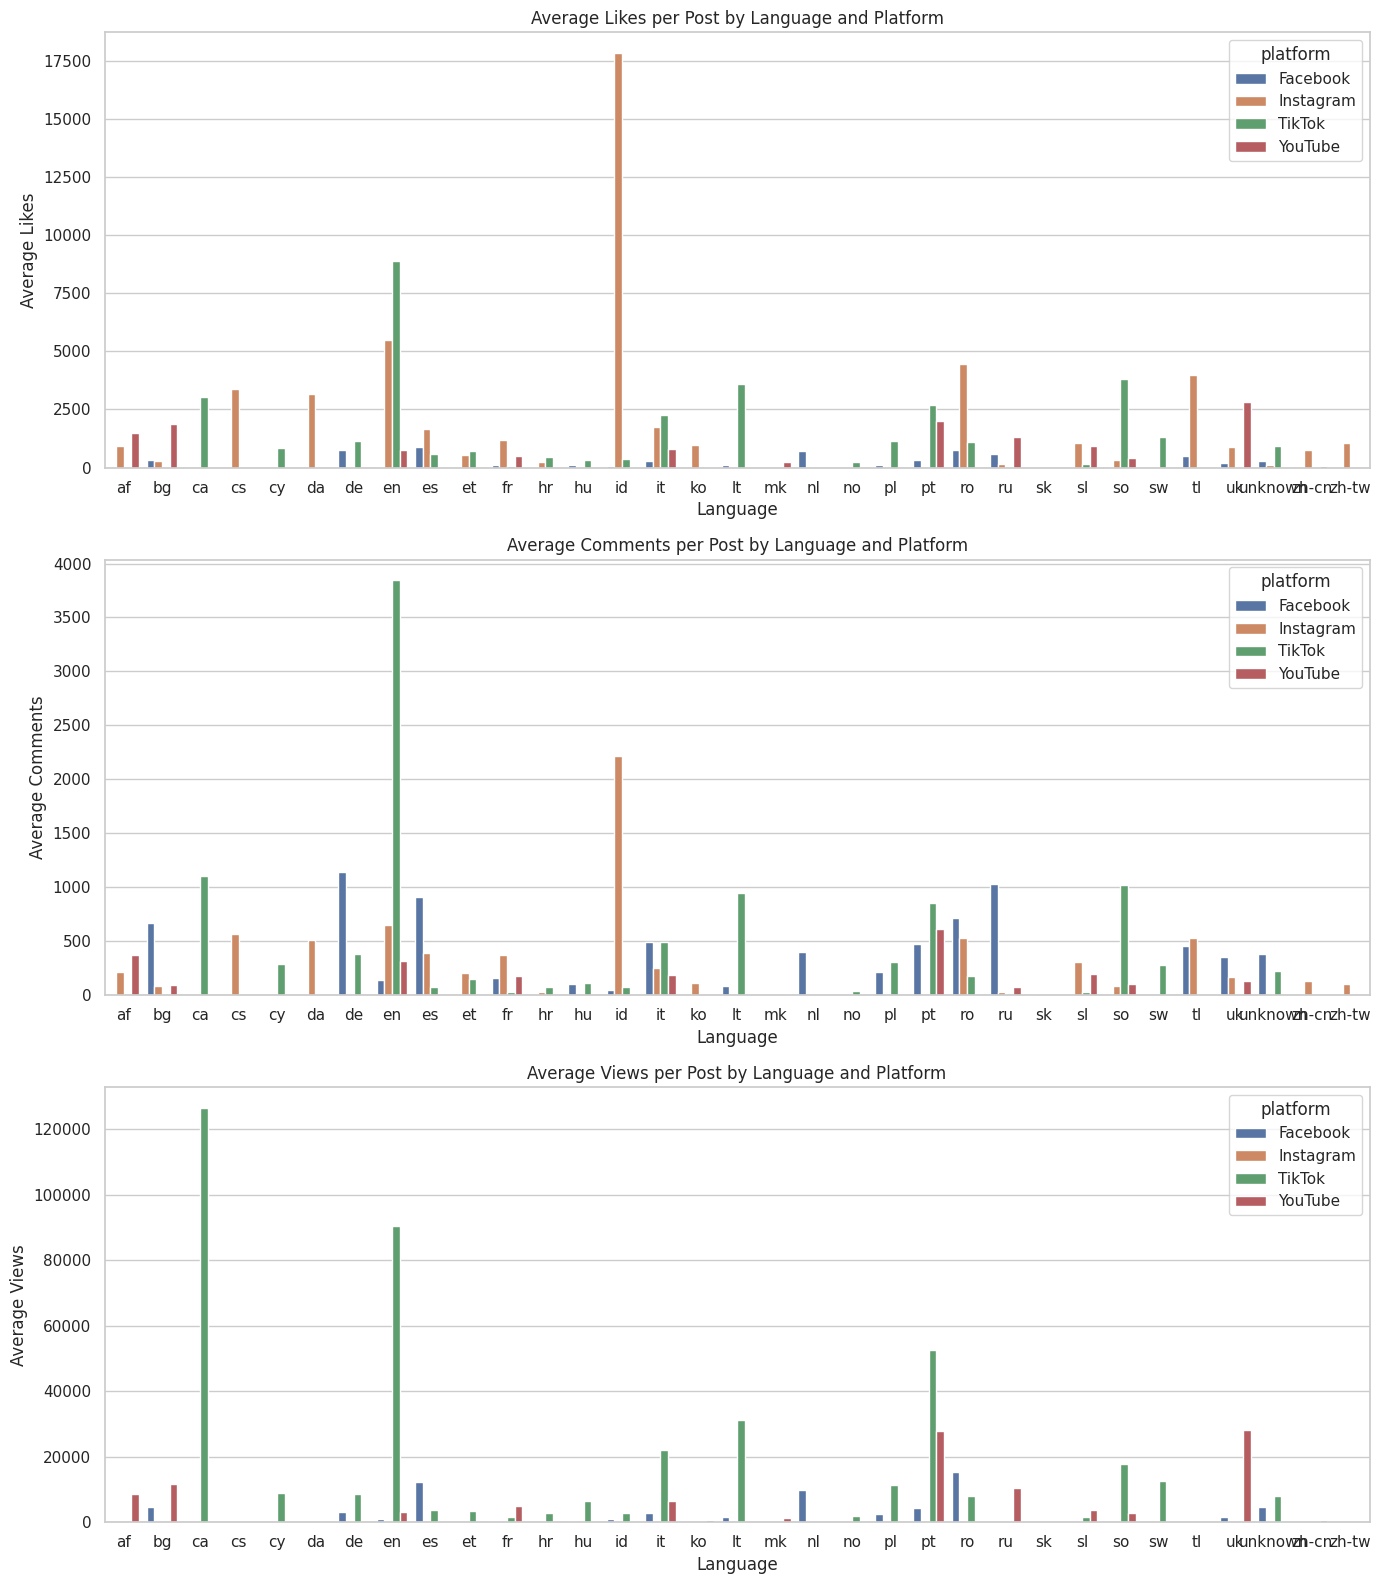

In [202]:
# Create DataFrame for average engagement per post
df_avg_engagement = (
    df_cleaned.groupby(['language', 'platform'], observed=False)
    .agg(
        avg_likes=('likes_count', 'mean'),
        avg_comments=('comments_count', 'mean'),
        avg_views=('views_count', 'mean')
    )
    .reset_index()
)

# Plot settings
sns.set(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

# 1️⃣ Average likes
sns.barplot(ax=axes[0], data=df_avg_engagement, x='language', y='avg_likes', hue='platform')
axes[0].set_title("Average Likes per Post by Language and Platform")
axes[0].set_ylabel("Average Likes")
axes[0].set_xlabel("Language")

# 2️⃣ Average comments
sns.barplot(ax=axes[1], data=df_avg_engagement, x='language', y='avg_comments', hue='platform')
axes[1].set_title("Average Comments per Post by Language and Platform")
axes[1].set_ylabel("Average Comments")
axes[1].set_xlabel("Language")

# 3️⃣ Average views
sns.barplot(ax=axes[2], data=df_avg_engagement, x='language', y='avg_views', hue='platform')
axes[2].set_title("Average Views per Post by Language and Platform")
axes[2].set_ylabel("Average Views")
axes[2].set_xlabel("Language")

plt.tight_layout()
plt.show()

In [ ]:
# Text length in characters and words
df_cleaned['text_length_chars'] = df_cleaned['text_original'].fillna('').apply(len)
df_cleaned['text_length_words'] = df_cleaned['text_original'].fillna('').apply(lambda x: len(x.split()))

# Calculate average engagement by text length
length_engagement = df_cleaned.groupby(pd.qcut(df_cleaned['text_length_words'], q=5), observed=False)[
    ['likes_count', 'shares_count', 'comments_count']
].mean()

print("Average engagement by text length (by quintiles):")
display(length_engagement.round(2))

Average engagement by text length (by quintiles):


,likes_count,shares_count,comments_count
text_length_words,,,
"(-0.001, 1.0]",502.72,58.55,345.20
"(1.0, 12.0]",1291.91,95.41,261.94
"(12.0, 25.0]",1380.19,77.65,356.17
"(25.0, 51.0]",2327.30,144.37,337.70
"(51.0, 1536.0]",1607.01,35.39,209.44


In [ ]:
# Collect all hashtags
hashtags = df_cleaned['text_original'].dropna().apply(lambda x: re.findall(r"#\w+", x))
hashtags_flat = [tag.lower() for sublist in hashtags for tag in sublist]

# Top 10 hashtags
top_hashtags = Counter(hashtags_flat).most_common(10)
print("Top 10 hashtags:")
for tag, count in top_hashtags:
    print(f"{tag}: {count}")

Top 10 hashtags:
#preghiera: 874
#jezus: 871
#gesù: 836
#молитва: 731
#бог: 688
#modlitwa: 669
#bóg: 600
#wiara: 566
#господь: 533
#dio: 442


## 5. Conclusion

### Posts and Activity by Platform

By number of posts, three platforms – Facebook, TikTok, and YouTube – have roughly the same number of posts (about 2,500 each), while Instagram is slightly behind (1,837 posts).
Looking at total engagement metrics, TikTok and YouTube lead in views (≈39M and ≈56M respectively), indicating a large audience and reach. Instagram has a significant number of likes (≈2.8M) but almost no data for views and shares, while Facebook shows moderate numbers across all metrics.
Thus, different platforms engage audiences in different ways: TikTok and YouTube are better for reach, Instagram is stronger for likes.

### Number of Unique Accounts and Top Active Users

The analysis shows that activity is concentrated among a small number of users. The top 10 accounts post between 280 and 409 posts, and the top 10 by engagement receive millions of likes and tens of millions of views. Most of the most influential accounts are on YouTube and Instagram.
This indicates that influence and activity are focused on "star" (popular) users, who can be targeted for advertising, and whose content can serve as examples of what interests the audience.

### Popular Posting Times and Weekdays

Most posts are made on Mondays and Fridays. The peak posting hour is 9:00 AM, but there is also notable activity at 5:00, 3:00 PM, and 5:00 PM.
This information helps plan posts for the days and hours when the audience is most active, increasing visibility and engagement.

### Statistics and Correlation of Engagement Metrics

The average number of likes per post is ≈1412, views ≈17,973, comments ≈302, and shares ≈79, with some large outliers (up to 3.5 million views and almost 190k likes).
Correlation between metrics shows that likes and views are strongly related (0.92), likes and shares also correlate well (0.76), while comments are less correlated with other metrics (≈0.5).
This means popular posts get likes and views together, but comments behave more independently.

### Language and Post Text Analysis

The analysis shows that most posts are in Italian (it) and Ukrainian (uk), but the average engagement per post in these languages is lower than in languages with fewer posts, like Indonesian (id) or Tagalog (tl).
This indicates that a large audience does not always guarantee high engagement per post. Platform also plays a key role: Instagram leads for Italian, Korean, and Bulgarian, TikTok for Polish, and YouTube for English and French content.
Overall, smaller language communities show higher average engagement per post, while large-language posts have more spread-out likes, comments, and views. This helps understand which languages and platforms give the most reach and audience activity.

### Text Length and Engagement

Posts with text length between 25 and 51 words get the highest average likes (≈2327) and shares (≈144), while very short (<1 word) or very long (>50 words) posts get less engagement.
This suggests a "sweet spot" for text length that is optimal for maximizing audience engagement.


### Hashtags and Topics

The top 10 hashtags show that users often use religious themes: #preghiera, #jezus, #молитва, #бог, etc.
This helps to understand which hashtags can attract more attention and reach the audience, and which topics interest users, allowing content strategy to focus on trending and popular themes.


